<a href="https://colab.research.google.com/github/msfasha/307102-Descriptive-Statistics-for-Business/blob/main/3_time_series_ml_prophet_tutorial_ipynb_txt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 3 - Time Series Analysis with Prophet and Machine Learning



In this tutorial, we will forecast monthly airline passenger numbers using two approaches:

1. **Prophet**, a forecasting library designed for trend and seasonality.
2. **Machine learning**, using manually engineered time-series features.

We will use the real `flights` dataset from Seaborn. It contains monthly airline passenger counts from 1949 to 1960.


## Introduction to Prophet

**Prophet** is an open-source forecasting library developed by Meta (formerly Facebook) and released in 2017. It is designed to make time series forecasting accessible to analysts and data scientists who may not have deep expertise in time series modeling.

### What makes Prophet different?

Most classical forecasting methods (like ARIMA) require the user to manually identify the model order, handle stationarity, and tune parameters carefully. Prophet takes a different approach:

- It fits an **additive regression model** with interpretable components: trend, seasonality, and holidays.
- It is designed to handle **missing data**, **outliers**, and **irregular time series** gracefully.
- It requires minimal configuration and works well out of the box on many real-world datasets.

### How Prophet works

Prophet decomposes a time series into three main components:

$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

| Component | Description |
|-----------|-------------|
| $g(t)$ | **Trend** — models non-periodic changes (linear or logistic growth) |
| $s(t)$ | **Seasonality** — models periodic patterns (yearly, weekly, daily) using Fourier series |
| $h(t)$ | **Holidays** — models the effect of user-specified special events |
| $\epsilon_t$ | **Error** — captures any remaining unexplained variation |

### When to use Prophet

Prophet works best when:

- The time series has at least a few months of historical data.
- There are clear seasonal patterns (e.g., yearly cycles).
- The data may contain missing values or occasional outliers.
- You need a fast, interpretable baseline forecast without extensive manual tuning.

### Input format

Prophet requires a DataFrame with exactly two columns:

- `ds` — the datestamp column (datetime format)
- `y` — the numeric value to forecast

This tutorial uses the classic airline passengers dataset to demonstrate both Prophet and a machine learning alternative.

<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">0. Install Required Libraries</h3>
</div>

Run this cell only if the required libraries are not already installed in your environment.

`prophet` can sometimes take a little longer to install because it depends on forecasting-related backend packages.

In [1]:
# Uncomment and run if needed:
!pip install prophet seaborn scikit-learn matplotlib pandas

<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">1. Import Libraries</h3>
</div>

We import libraries for:

- data manipulation
- visualization
- forecasting with Prophet
- machine learning with Random Forest
- model evaluation using MAE and RMSE

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from prophet import Prophet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">2. Load the Dataset</h3>
</div>

The `flights` dataset (from Seaborn) contains monthly airline passenger counts and is a classic benchmark for time-series forecasting.

Why this dataset is useful:

- It spans **1949 to 1960** (12 years).
- It has **144 monthly observations** (12 months × 12 years).
- It shows a clear long-term upward trend in passenger volume.
- It also has repeating yearly seasonality (similar patterns across months each year).

The original columns are:

- `year`
- `month`
- `passengers`

Prophet requires two specific column names:

- `ds`: the date column
- `y`: the target value we want to forecast

So we convert the original dataset into Prophet's expected format by building a proper monthly datetime column and renaming `passengers` to `y`.

In [3]:
df = sns.load_dataset("flights")



In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB


In [6]:
# Parse strings into pandas datetime values for time-aware operations.
df["ds"] = pd.to_datetime(
    df["year"].astype(str) + "-" + df["month"].astype(str) + "-01"
)

df = df[["ds", "passengers"]].rename(columns={"passengers": "y"})

df.head()

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">3. Visualize the Time Series</h3>
</div>

Before building a model, always plot the data.

This helps us identify:

- the overall trend
- yearly seasonality
- unusual observations
- whether the series is increasing, decreasing, or stable

This dataset clearly shows an upward trend and seasonal fluctuations.

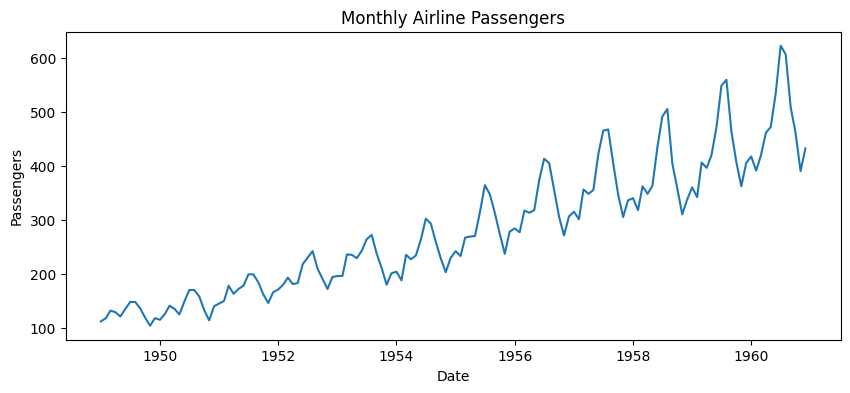

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(df["ds"], df["y"])
plt.title("Monthly Airline Passengers")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.show()

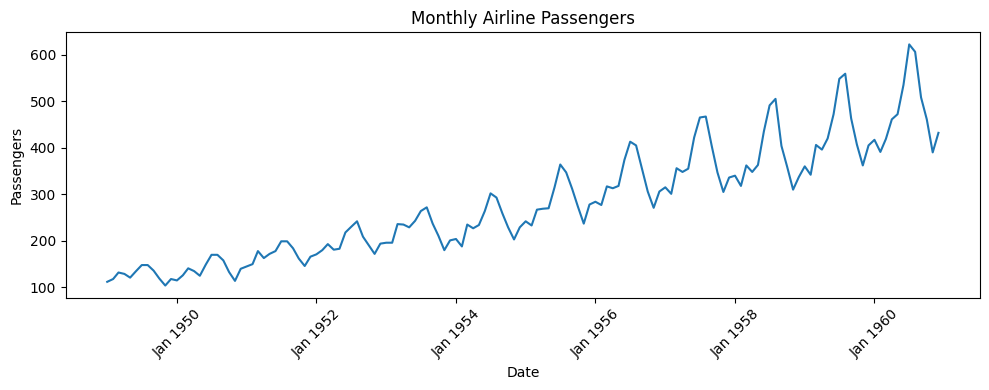

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(10, 4))
plt.plot(df["ds"], df["y"])

plt.title("Monthly Airline Passengers")
plt.xlabel("Date")
plt.ylabel("Passengers")

ax = plt.gca()

# Show month and year (e.g., Jan 1949)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">4. Split the Data</h3>
</div>

For time series forecasting, we do **not** randomly split the data.

Instead, we train on older observations and test on future observations.

Here, we use:

- all data except the final 12 months for training
- the final 12 months for testing

This simulates a realistic forecasting situation.

In [10]:
train = df.iloc[:-12]
test = df.iloc[-12:]

print("Training data shape:", train.shape)
print("Testing data shape:", test.shape)

Training data shape: (132, 2)
Testing data shape: (12, 2)


<div style="
    background-color:#8F0177;
    padding:20px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h2 style="margin:0;">Forecasting with Prophet</h2>
</div>

Prophet is designed for time series that contain trend and seasonality.

It is commonly used when we want a fast forecasting baseline with interpretable components.

Our data is monthly, so we enable yearly seasonality and disable weekly and daily seasonality.

In [13]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

# Train the model parameters using the provided dataset.
model.fit(train)

<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">5. Create Future Dates</h3>
</div>

Prophet does not automatically know how far into the future we want to forecast.

We use `make_future_dataframe()` to create future dates.

Because the dataset is monthly, we use `freq="MS"`, which means month start frequency.

We add 12 future months because our test set contains 12 months.

In [15]:
# Create future timestamps for forecasting horizon.

future = model.make_future_dataframe(periods=12, freq="MS")

future.tail()

,ds
139,1960-08-01
140,1960-09-01
141,1960-10-01
142,1960-11-01
143,1960-12-01


<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">6. Generate the Forecast</h3>
</div>

The `predict()` method generates the forecast.

The most important forecast columns are:

- `ds`: the date
- `yhat`: the predicted value
- `yhat_lower`: the lower uncertainty estimate
- `yhat_upper`: the upper uncertainty estimate

We display the final 12 rows because those correspond to the forecast period.

In [17]:
# Generate predictions for historical and future timestamps.
forecast = model.predict(future)

forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(12)

,ds,yhat,yhat_lower,yhat_upper
132,1960-01-01,424.881294,399.026493,449.297738
133,1960-02-01,421.489428,394.590945,448.766018
134,1960-03-01,457.002985,432.676537,482.110000
135,1960-04-01,451.393875,427.156678,477.073145
136,1960-05-01,453.900819,427.597511,479.691027
137,1960-06-01,493.715546,467.481779,517.385374
138,1960-07-01,523.845021,498.478145,549.926307
139,1960-08-01,527.280362,502.311313,555.034524
140,1960-09-01,486.059030,460.030630,510.299010
141,1960-10-01,452.372616,425.892789,477.315793


<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">7. Evaluate Prophet</h3>
</div>

We compare the Prophet forecast against the actual values in the test set.

We use two common metrics:

- **MAE**: Mean Absolute Error. Lower is better.
- **RMSE**: Root Mean Squared Error. Lower is better, and large errors are penalized more strongly.

In [18]:
prophet_pred = forecast.iloc[-12:]["yhat"]

prophet_mae = mean_absolute_error(test["y"], prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(test["y"], prophet_pred))

print("Prophet MAE:", prophet_mae)
print("Prophet RMSE:", prophet_rmse)

Prophet MAE: 33.434522332343725
Prophet RMSE: 43.067854056122655


<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">8. Plot the Prophet Forecast</h3>
</div>

This plot shows:

- the historical data
- the forecasted future values
- the uncertainty interval around the forecast

The uncertainty interval gives a range of plausible future values, not a guaranteed boundary.

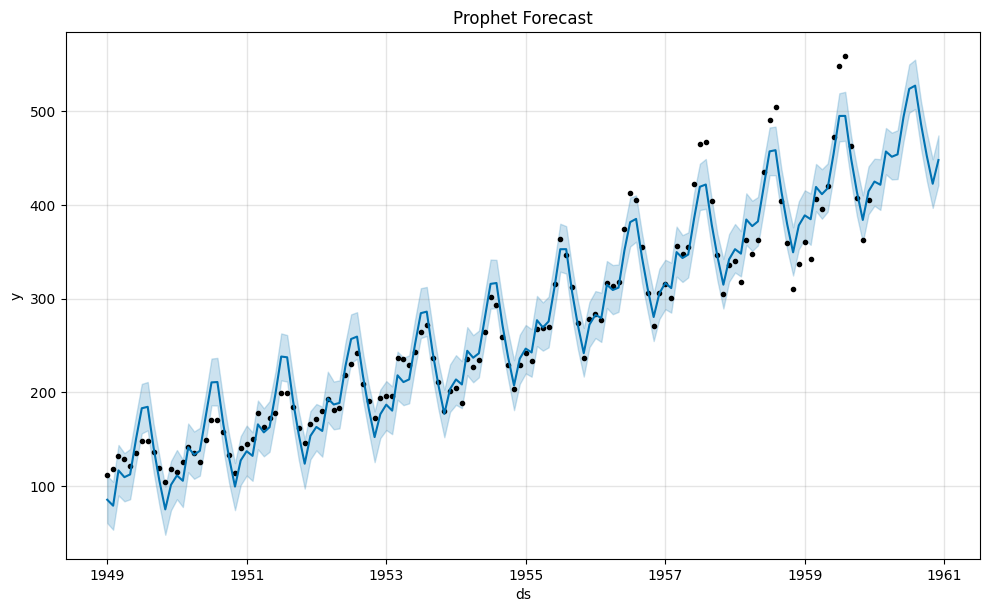

In [19]:
fig = model.plot(forecast)
plt.title("Prophet Forecast")
plt.show()

<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">9. Plot Prophet Components</h3>
</div>

Prophet decomposes the forecast into components.

For this dataset, the most useful components are:

- trend
- yearly seasonality

This makes Prophet more interpretable than many black-box machine learning models.

In [ ]:
# Plot trend and seasonal components learned by the model.fig = model.plot_components(forecast)
plt.show()

<div style="
    background-color:#8F0177;
    padding:20px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h2 style="margin:0;">Part 2: Machine Learning for Time Series</h2>
</div>

Most machine learning models do not understand time automatically.

We must convert the time series into a supervised learning problem by creating useful features.

Examples of time-series features include:

- month
- year
- time index
- previous values
- rolling averages

This process is called **feature engineering**.

In [ ]:
ml_df = df.copy()

ml_df["month"] = ml_df["ds"].dt.month
ml_df["year"] = ml_df["ds"].dt.year
ml_df["time_index"] = range(len(ml_df))

ml_df["lag_1"] = ml_df["y"].shift(1)
ml_df["lag_12"] = ml_df["y"].shift(12)
ml_df["rolling_3"] = ml_df["y"].shift(1).rolling(3).mean()

ml_df = ml_df.dropna()

ml_df.head()

<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">10. Understand the Engineered Features</h3>
</div>

The new features are:

- `month`: captures yearly seasonality
- `year`: captures long-term growth
- `time_index`: captures the passage of time as a numeric feature
- `lag_1`: the passenger count from the previous month
- `lag_12`: the passenger count from the same month last year
- `rolling_3`: the average passenger count over the previous 3 months

Notice that we use `.shift(1)` before rolling.

This prevents **data leakage**, because the model should not use the current month's value to predict the current month.

In [ ]:
features = ["month", "year", "time_index", "lag_1", "lag_12", "rolling_3"]

features

<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">11. Split the Machine Learning Data</h3>
</div>

After creating lag features, the first rows contain missing values and were removed.

We again use the final 12 rows as the test set.

This keeps the comparison with Prophet fair.

In [ ]:
train_ml = ml_df.iloc[:-12]
test_ml = ml_df.iloc[-12:]

X_train = train_ml[features]
y_train = train_ml["y"]

X_test = test_ml[features]
y_test = test_ml["y"]

print("ML training data shape:", X_train.shape)
print("ML testing data shape:", X_test.shape)

<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">12. Train a Random Forest Model</h3>
</div>

Random Forest is a general-purpose machine learning model.

It can learn nonlinear relationships, but it does not naturally understand time.

That is why our lag and calendar features are important.

In [ ]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

# Train the model parameters using the provided dataset.rf.fit(X_train, y_train)

<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">13. Predict Using the Random Forest Model</h3>
</div>

Now we use the trained Random Forest model to predict the final 12 months.

These predictions will be compared with both the real values and the Prophet predictions.

In [ ]:
# Generate predictions for historical and future timestamps.rf_pred = rf.predict(X_test)

rf_pred

<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">14. Evaluate the Random Forest Model</h3>
</div>

We calculate the same metrics used for Prophet.

Using the same metrics makes the comparison fair and easy to interpret.

In [ ]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">15. Compare Both Models Visually</h3>
</div>

Finally, we plot:

- the actual values
- Prophet predictions
- Random Forest predictions

Visual comparison is important because metrics alone do not show whether the model captures the overall pattern of the time series.

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(test["ds"], test["y"], label="Actual")
plt.plot(test["ds"], prophet_pred, label="Prophet")
plt.plot(test_ml["ds"], rf_pred, label="Random Forest")

plt.title("Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.show()

<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">Summary</h3>
</div>

In this tutorial, we used two forecasting approaches.

**Prophet** is simple and useful when the time series has clear trend and seasonality.

**Machine learning models** can also forecast time series, but they need carefully designed features.

Important lessons:

- Do not randomly split time-series data.
- Train on the past and test on the future.
- Prophet expects columns named `ds` and `y`.
- ML models need lag features, rolling features, and date features.
- Always evaluate forecasts using future data.